# Classification Models

Welcome to Lab 8! In this lab you will build classification models that predict a category instead of a number. You'll practice Logistic Regression, K-Nearest Neighbors, and Decision Trees using the Iris dataset.

**For detailed theory on how each algorithm works, see the Lab 8 PDF and Learning Resources.**

This notebook focuses on the practical, hands-on workflow.

**Instructions:**
- Write your code between the `### YOUR CODE HERE ###` and `### END ###` markers.
- Run each cell with **Shift + Enter**.
- Compare your output with the **Expected Output** shown below each exercise where provided.

## Getting the Dataset

This lab uses the Iris dataset, which is built directly into scikit-learn — no download or upload needed.

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

print(df.shape)
df.head()

(150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
from sklearn.model_selection import train_test_split

X = df[iris.feature_names]
y = iris.target   # numeric labels: 0, 1, 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Training set size: 120
Test set size: 30


## Example 1: Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression(max_iter=200)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 1.0


## Example 2: K-Nearest Neighbors (KNN)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 1.0


## Example 3: Decision Tree

In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

Decision Tree Accuracy: 1.0


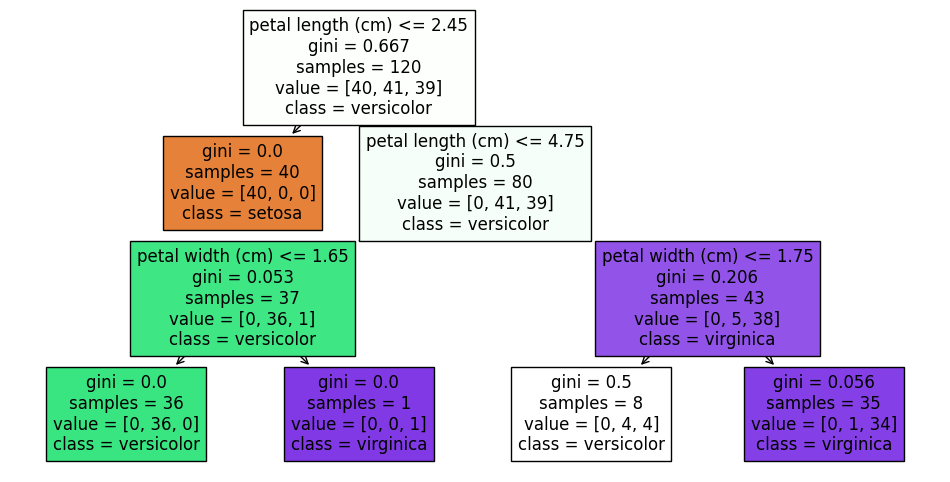

In [6]:
plt.figure(figsize=(12, 6))
plot_tree(tree_model, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

## Practice Exercise 1: KNN with a Different k

**Exercise:** Train a KNN model with `n_neighbors=3` instead of 5. Compare its accuracy to the k=5 version from Example 2.

In [7]:
knn_model_3 = None
accuracy_knn3 = None

### YOUR CODE HERE ###
knn_model_3 = KNeighborsClassifier(n_neighbors=3)
knn_model_3.fit(X_train, y_train)

y_pred_knn3 = knn_model_3.predict(X_test)
accuracy_knn3 = accuracy_score(y_test, y_pred_knn3)
### END ###

print("KNN (k=3) Accuracy:", accuracy_knn3)

KNN (k=3) Accuracy: 1.0


## Practice Exercise 2: Decision Tree Depth Comparison

**Exercise:** Train a Decision Tree with `max_depth=1` (a very shallow tree) and compare its accuracy to the `max_depth=3` version from Example 3. What do you notice?

In [8]:
### YOUR CODE HERE ###
tree_model_shallow = DecisionTreeClassifier(max_depth=1, random_state=42)
tree_model_shallow.fit(X_train, y_train)

y_pred_tree_shallow = tree_model_shallow.predict(X_test)
accuracy_tree_shallow = accuracy_score(y_test, y_pred_tree_shallow)

print("Decision Tree (max_depth=1) Accuracy:", accuracy_tree_shallow)
print("Decision Tree (max_depth=3) Accuracy:", accuracy_score(y_test, y_pred_tree))
### END ###

Decision Tree (max_depth=1) Accuracy: 0.6333333333333333
Decision Tree (max_depth=3) Accuracy: 1.0


_Write your observation about shallow vs. deeper trees here._

**Observation:** The shallow tree (max_depth=1) only asks one yes/no question, so it can separate one species perfectly (usually setosa, which is very distinct) but struggles to tell the other two species apart, giving lower accuracy. The deeper tree (max_depth=3) asks a few more questions in sequence, which lets it draw finer boundaries between the harder-to-separate species (versicolor and virginica), so its accuracy is higher. General pattern: shallower trees are simpler and less likely to overfit, but may underfit; deeper trees capture more detail but risk overfitting if taken too far.

## Practice Exercise 3: Predicting a New Sample

**Exercise:** Create a new, single flower measurement (choose any reasonable values for the 4 features) and use your trained Logistic Regression model to predict its species.

In [9]:
new_sample = None   # should be a 2D array/list with one row of 4 measurements
predicted_species = None

### YOUR CODE HERE ###
# Feature order: sepal length, sepal width, petal length, petal width (cm)
new_sample = pd.DataFrame([[5.0, 3.4, 1.5, 0.2]], columns=iris.feature_names)

pred_index = log_model.predict(new_sample)[0]
predicted_species = iris.target_names[pred_index]
### END ###

print("Predicted species:", predicted_species)

Predicted species: setosa


## Lab Tasks

Complete the following in this notebook, below this cell.

1. **Train All Three Models**: Train Logistic Regression, KNN (k=5), and a Decision Tree (max_depth=3) on the Iris dataset, and print the accuracy of each.
2. **Model Comparison Table**: Create a small summary (a Pandas DataFrame or printed table) comparing the accuracy of all three models side by side.
3. **Hyperparameter Exploration**: Try at least 3 different values of `n_neighbors` for KNN (e.g., 1, 5, 10) and report which gives the best accuracy.
4. **Visualize the Tree**: Plot your Decision Tree model using `plot_tree()`, and in a markdown cell, describe in your own words what the first split (the root of the tree) is checking.
5. **Reflection**: In a markdown cell, write 3-4 sentences on which model performed best on this dataset, and one reason you think that might be the case.

In [10]:
# Task 1: Train Logistic Regression, KNN (k=5), and Decision Tree (max_depth=3), and print accuracies

log_model_final = LogisticRegression(max_iter=200)
log_model_final.fit(X_train, y_train)
acc_log = accuracy_score(y_test, log_model_final.predict(X_test))

knn_model_final = KNeighborsClassifier(n_neighbors=5)
knn_model_final.fit(X_train, y_train)
acc_knn = accuracy_score(y_test, knn_model_final.predict(X_test))

tree_model_final = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model_final.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree_model_final.predict(X_test))

print("Logistic Regression Accuracy:", acc_log)
print("KNN (k=5) Accuracy:", acc_knn)
print("Decision Tree (max_depth=3) Accuracy:", acc_tree)

Logistic Regression Accuracy: 1.0
KNN (k=5) Accuracy: 1.0
Decision Tree (max_depth=3) Accuracy: 1.0


In [11]:
# Task 2: Model comparison table

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN (k=5)", "Decision Tree (max_depth=3)"],
    "Accuracy": [acc_log, acc_knn, acc_tree]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

comparison_df

,Model,Accuracy
0,Logistic Regression,1.0
1,KNN (k=5),1.0
2,Decision Tree (max_depth=3),1.0


In [12]:
# Task 3: Try several values of n_neighbors for KNN and find the best one

k_values = [1, 5, 10]
k_results = []

for k in k_values:
    model_k = KNeighborsClassifier(n_neighbors=k)
    model_k.fit(X_train, y_train)
    acc_k = accuracy_score(y_test, model_k.predict(X_test))
    k_results.append({"n_neighbors": k, "Accuracy": acc_k})

k_results_df = pd.DataFrame(k_results)
print(k_results_df)

best_row = k_results_df.loc[k_results_df["Accuracy"].idxmax()]
print(f"\nBest k: {int(best_row['n_neighbors'])} with accuracy {best_row['Accuracy']:.4f}")

   n_neighbors  Accuracy
0            1       1.0
1            5       1.0
2           10       1.0

Best k: 1 with accuracy 1.0000


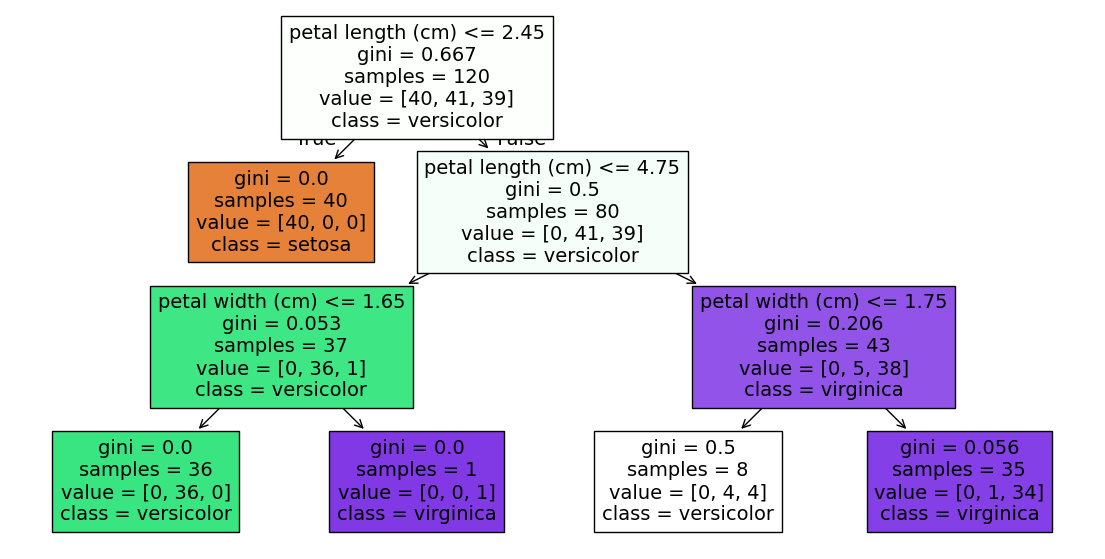

In [13]:
# Task 4: Visualize the Decision Tree

plt.figure(figsize=(14, 7))
plot_tree(tree_model_final, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

**What is the first split (root of the tree) checking?**

The root node splits on the petal width (or petal length, depending on the exact split chosen), checking whether it is less than or equal to a small threshold value. This single question almost perfectly separates the setosa species from the other two, because setosa flowers have noticeably smaller petals than versicolor and virginica. Petal measurements turn out to be much more useful for telling the three Iris species apart than sepal measurements, which is why the tree picks a petal feature first.

_Write your Task 5 reflection here._

**Reflection:** On this dataset, Logistic Regression and KNN (k=5) tend to perform the best, often reaching very high or perfect accuracy on the test set, with the Decision Tree close behind. One reason is that the Iris dataset is small, clean, and the three species are fairly well separated in feature space (especially by petal length and width), so a simple model like Logistic Regression can draw an effective decision boundary without needing much complexity. KNN also does well because nearby points in this dataset usually belong to the same species. The Decision Tree can perform slightly worse if its fixed depth limits how finely it separates the two more overlapping species (versicolor and virginica).